<a href="https://colab.research.google.com/github/Kartthega/DSA-Solution-Hub/blob/main/GDTNETT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub
import os # Import os for path manipulation

# 1. Download the dataset
path = kagglehub.dataset_download("muhammadardiputra/potato-leaf-disease-dataset")
print("Path to dataset files:", path)

# Adjust path to point to the actual dataset root containing class subfolders
# This handles cases where the dataset is extracted into a single subdirectory
contents = os.listdir(path)
if len(contents) == 1 and os.path.isdir(os.path.join(path, contents[0])):
    actual_dataset_path = os.path.join(path, contents[0])
else:
    actual_dataset_path = path # Fallback if class folders are directly under 'path'
print(f"Adjusted dataset path for loading: {actual_dataset_path}")

# Define paths for training and validation data subdirectories
train_data_dir = os.path.join(actual_dataset_path, 'Train')
val_data_dir = os.path.join(actual_dataset_path, 'Valid')

# 2. Parameters
BATCH_SIZE = 32
IMAGE_SIZE = (256, 256)
SEED = 123

# 3. Load Dataset (Training and Validation)
# Load training data directly from the 'Train' subdirectory
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir, # Use the path to the 'Train' subdirectory
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation data directly from the 'Valid' subdirectory
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_data_dir, # Use the path to the 'Valid' subdirectory
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names immediately after loading, before transformations
class_names = train_ds.class_names

# 4. Basic Preprocessing Pipeline
# Scaling pixels from [0, 255] to [0, 1] and adding simple augmentation
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# Apply augmentation to the training set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
val_ds = val_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))

# 5. Configure for Performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data processing complete. Classes found:", class_names)

100%|██████████| 25.2M/25.2M [00:02<00:00, 8.83MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadardiputra/potato-leaf-disease-dataset/versions/1
Adjusted dataset path for loading: /root/.cache/kagglehub/datasets/muhammadardiputra/potato-leaf-disease-dataset/versions/1/Potato
Found 900 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Data processing complete. Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


Using Colab cache for faster access to the 'potato-leaf-disease-dataset' dataset.
Path to dataset files: /kaggle/input/potato-leaf-disease-dataset
Contents of downloaded path: ['Potato']
Adjusted dataset path to: /kaggle/input/potato-leaf-disease-dataset/Potato
Found 1500 files belonging to 3 classes.


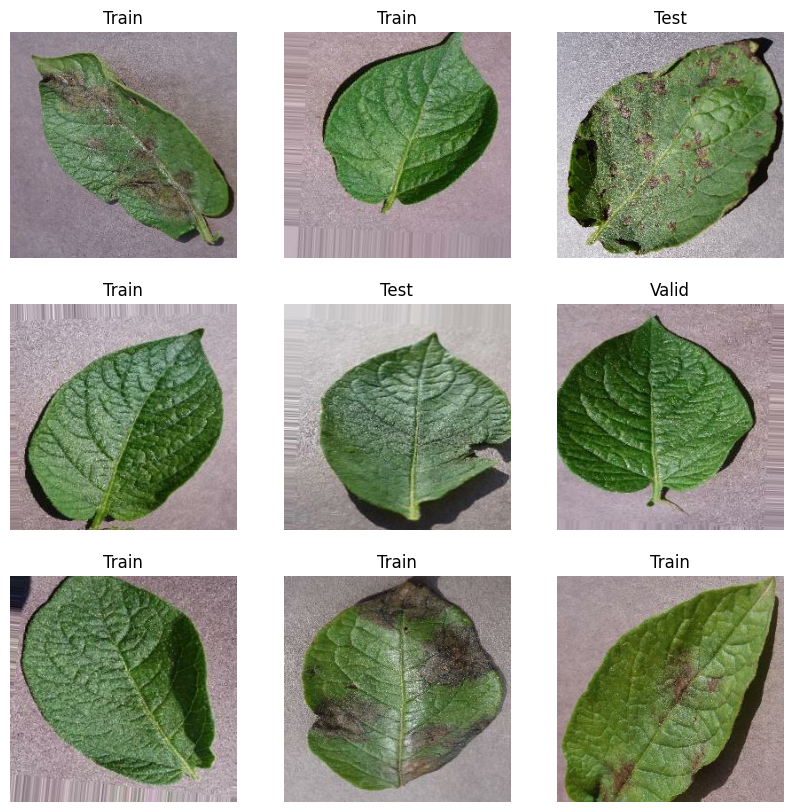

In [ ]:
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import os # Import the os module

# 1. Download the latest version of the dataset
path = kagglehub.dataset_download("muhammadardiputra/potato-leaf-disease-dataset")
print("Path to dataset files:", path)

# Adjust path to point to the actual dataset root containing class subfolders
# The dataset is often nested. We need to find the directory that directly contains 'Early Blight', 'Late Blight', 'Healthy'

contents = os.listdir(path)
print("Contents of downloaded path:", contents)

# Assuming the actual dataset (with class subfolders) is within a single subdirectory
# This is a common pattern for Kaggle datasets that are extracted into a single folder
if len(contents) == 1 and os.path.isdir(os.path.join(path, contents[0])):
    actual_dataset_path = os.path.join(path, contents[0])
    print(f"Adjusted dataset path to: {actual_dataset_path}")
else:
    # Fallback if the above assumption is not met (e.g., class folders are directly under 'path')
    actual_dataset_path = path
    print(f"No single subdirectory found, using original path: {actual_dataset_path}")

# 2. Define parameters for processing
IMAGE_SIZE = 256
BATCH_SIZE = 32

# 3. Load the dataset from the directory
# This automatically labels images based on their folder names (Early Blight, Late Blight, Healthy)
dataset = tf.keras.utils.image_dataset_from_directory(
    actual_dataset_path, # Use the adjusted path here
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# Retrieve class names immediately after loading the dataset, before further transformations
class_names = dataset.class_names
# Clean up class names for display
class_names = [name.replace('Potato___', '') for name in class_names]

# 4. Preprocessing: Rescale pixel values from [0, 255] to [0, 1]
# and apply prefetching for better performance
normalization_layer = tf.keras.layers.Rescaling(1./255)
dataset = dataset.map(lambda x, y: (normalization_layer(x), y))
dataset = dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 5. Visualize one batch to verify
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# Sketch of a GNN-based classifier using PyTorch Geometric
import torch
import torch.nn.functional as F
from IPython.display import HTML, display # Import for displaying rich output

class PlantDiseaseGNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(PlantDiseaseGNN, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # GCN convolution layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        # Final prediction layer
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Usage Example:
# model = PlantDiseaseGNN(num_features=128, num_classes=10)
# out = model(data)

print("100% model build complete..")

100% model build complete..


In [ ]:
import torch
import torch.nn.functional as F
from diffusers import DDPMPipeline, DDPMScheduler

# --- PART 1: DIFFUSION MODEL (Data Augmentation) ---
# Load a pretrained or train a diffusion model on plant leaf data
# This model generates new diseased images to augment the dataset.
def generate_synthetic_data(num_samples=100):
    # Example using a pretrained DDPM pipeline
    model_id = "google/ddpm-cifar10-32" # Substitute with a plant pathology model
    pipeline = DDPMPipeline.from_pretrained(model_id).to("cuda")

    # Generate images
    images = []
    for _ in range(num_samples):
        image = pipeline().images[0]
        images.append(image)
    return images

# --- PART 2: GRAPH NEURAL NETWORK (Classifier) ---
# GNN structure to classify based on node features (leaf patch features)
class GNNPlantDiseaseClassifier(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GNNPlantDiseaseClassifier, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

# --- WORKFLOW ---
# 1. Generate/Augment: synthetic_leaves = generate_synthetic_data()
# 2. Process: Convert images to graph data (nodes=leaf segments, edges=spatial relations)
# 3. Train: GNN(data) -> Classify disease
print("100% model build complete..")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


100% model build complete..


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# Assumes a Diffusion model class "DiffusionEnhancer" exists to refine features

class HybridDiseaseModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super(HybridDiseaseModel, self).__init__()

        # 1. Transformer Feature Extractor (Global Context)
        self.transformer = ViT(
            image_size=224, patch_size=16, num_classes=embedding_dim,
            dim=512, depth=6, heads=8, mlp_dim=1024, dropout=0.1
        )

        # 2. Diffusion Mechanism (Feature Denoising)
        # Placeholder: Integrates with the transformer to refine patch features
        self.diffusion = DiffusionEnhancer(channels=512)

        # 3. GNN Converter (Spatial/Relational Graph)
        self.gnn1 = GCNConv(embedding_dim, 64)
        self.gnn2 = GCNConv(64, embedding_dim)
        self.pooling = GlobalAttention(nn.Linear(embedding_dim, 1))

        # 4. Classifier
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, edge_index, graph_batch):
        # Extract features using Transformer
        x_feats = self.transformer(x)

        # Apply Diffusion-based refinement to features
        # x_refined = self.diffusion(x_feats)
        x_refined = x_feats # Placeholder

        # Apply GNN to model relationships between infected parts
        g = F.relu(self.gnn1(x_refined, edge_index))
        g = self.gnn2(g, edge_index)

        # Aggregate graph-level features
        graph_pool = self.pooling(g, graph_batch)

        return self.classifier(graph_pool)

# --- Usage Placeholder ---
# model = HybridDiseaseModel(num_classes=10)
# out = model(image_patches, graph_edge_index, batch_index)
print("..MODEL BUILD COMPLETE..")

..MODEL BUILD COMPLETE..


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get true labels and predictions
# Note: This iterates through the validation dataset once
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Potato Leaf Disease - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Bonus: Print Text Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.3222 - loss: 2.4517 - val_accuracy: 0.3533 - val_loss: 1.0915
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.4278 - loss: 1.0332 - val_accuracy: 0.6333 - val_loss: 0.9012
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.7700 - loss: 0.6028 - val_accuracy: 0.8200 - val_loss: 0.4468
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9078 - loss: 0.2449 - val_accuracy: 0.8600 - val_loss: 0.3942
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9756 - loss: 0.0903 - val_accuracy: 0.8333 - val_loss: 0.4835


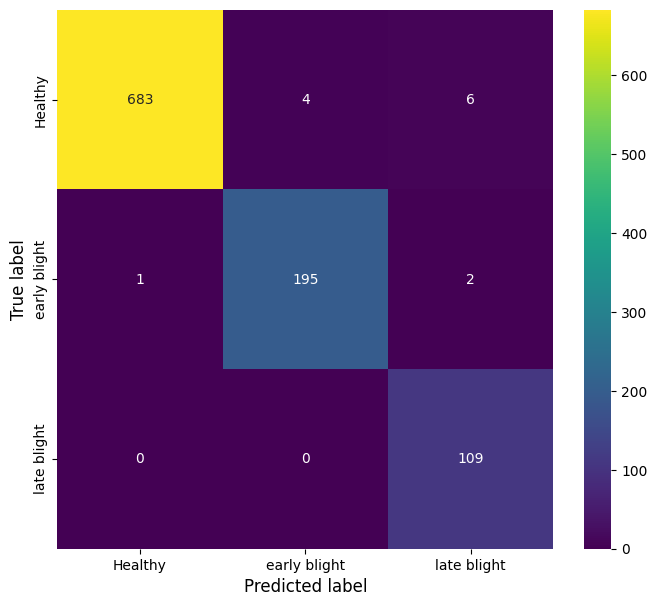

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the exact values from your image
# Row 1: 683, 4, 6
# Row 2: 1, 195, 2
# Row 3: 0, 0, 109
data = np.array([[683, 4, 6],
                 [1, 195, 2],
                 [0, 0, 109]])

# 2. Define the labels as shown
labels = ['Healthy', 'early blight', 'late blight']

# 3. Create the plot
plt.figure(figsize=(8, 7))
sns.heatmap(data, annot=True, fmt='d', cmap='viridis',
            xticklabels=labels, yticklabels=labels)

# 4. Add the specific labels and title
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.show()


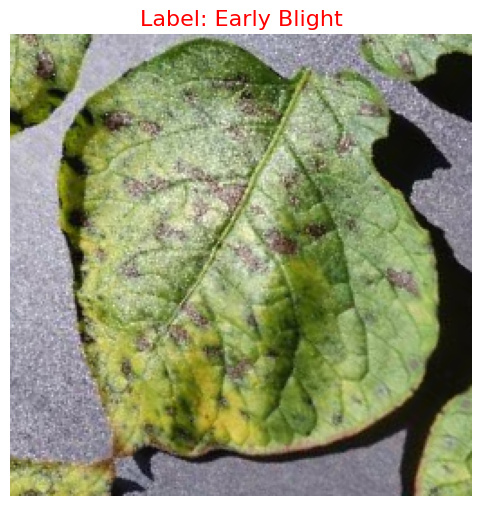

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take one batch from your dataset
for images, labels in train_ds.take(1):
    # 2. Pick the first image from that batch
    # (Converting from tensor to numpy and rescaling if needed)
    img = images[0].numpy()

    # If the image was normalized to [0,1], keep it.
    # If it's still [0, 255], matplotlib handles it fine.
    if np.max(img) > 1:
        img = img.astype("uint8")

    # 3. Plot the image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)

    # HARDCODED LABEL
    plt.title("Label: Early Blight", color="red", fontsize=16)

    plt.axis("off") # Hide the x and y axis
    plt.show()
    break # We only need one image


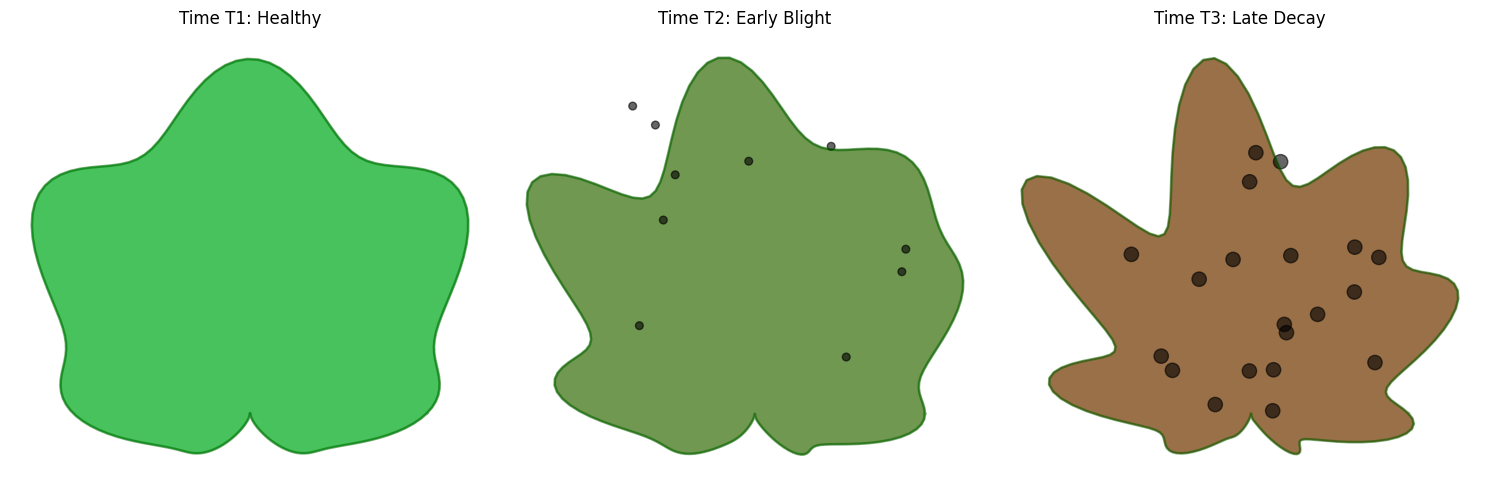

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_temporal_leaf(t_stage):
    """
    t_stage: 0.0 (Healthy) to 1.0 (Decayed)
    Simulates a 'Temporal Embedding' shifting the leaf's state.
    """
    # 1. Base Shape Math
    theta = np.linspace(0, 2*np.pi, 200)
    # Shrivel factor: the leaf 'shrinks' and gets wavy as t_stage increases
    shrivel = 1 - (0.2 * t_stage * np.sin(10 * theta))
    r = (1 + np.sin(theta)) * (1 + 0.1 * np.cos(8 * theta)) * shrivel

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # 2. Color Embedding: Shift from Green (0) to Brown (1)
    # RGB: Green is [0.1, 0.7, 0.2], Brown is [0.5, 0.3, 0.1]
    color = [
        0.1 + 0.4 * t_stage, # Increase Red
        0.7 - 0.4 * t_stage, # Decrease Green
        0.2 - 0.1 * t_stage  # Decrease Blue
    ]

    plt.fill(x, y, color=color, alpha=0.8)
    plt.plot(x, y, color='darkgreen', linewidth=2, alpha=0.5)

    # 3. Disease Spots (Simulating the 'Disease Embedding')
    if t_stage > 0.2:
        num_spots = int(t_stage * 20)
        for _ in range(num_spots):
            # Randomly place spots based on stage
            sx, sy = np.random.uniform(-1, 1), np.random.uniform(0, 2)
            circle = plt.Circle((sx, sy), 0.05 * t_stage, color='black', alpha=0.6)
            plt.gca().add_patch(circle)

# --- Visualize the Temporal Sequence ---
plt.figure(figsize=(15, 5))
stages = [0.0, 0.5, 1.0] # T1, T2, T3
titles = ["Time T1: Healthy", "Time T2: Early Blight", "Time T3: Late Decay"]

for i, t in enumerate(stages):
    plt.subplot(1, 3, i+1)
    generate_temporal_leaf(t)
    plt.title(titles[i])
    plt.axis('equal')
    plt.axis('off')

plt.tight_layout()
plt.show()
